In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
from astropy.table import Table


from mock_config import CONFIG, TF_FULL 

cosmo = FlatLambdaCDM(H0=100., Om0=0.3151)

In [12]:
d_data = Table.read(CONFIG.data_tf_full).to_pandas()
print(len(d_data))
data_label = f'TF full {CONFIG.data_tf_full_version}' 

35666


In [3]:
d_data.columns

Index(['SGA_ID', 'SGA_GALAXY', 'GALAXY', 'PGC', 'RA_LEDA', 'DEC_LEDA',
       'MORPHTYPE', 'PA_LEDA', 'D25_LEDA', 'BA_LEDA',
       ...
       'R_ABSMAG_SB26_TF', 'R_ABSMAG_SB26_TF_ERR', 'R_ABSMAG_SB26_TF_ERR_STAT',
       'R_ABSMAG_SB26_TF_ERR_SYS', 'MU_TF', 'MU_TF_ERR', 'LOGDIST',
       'LOGDIST_ERR', 'OUTLIER', 'MAIN'],
      dtype='str', length=155)

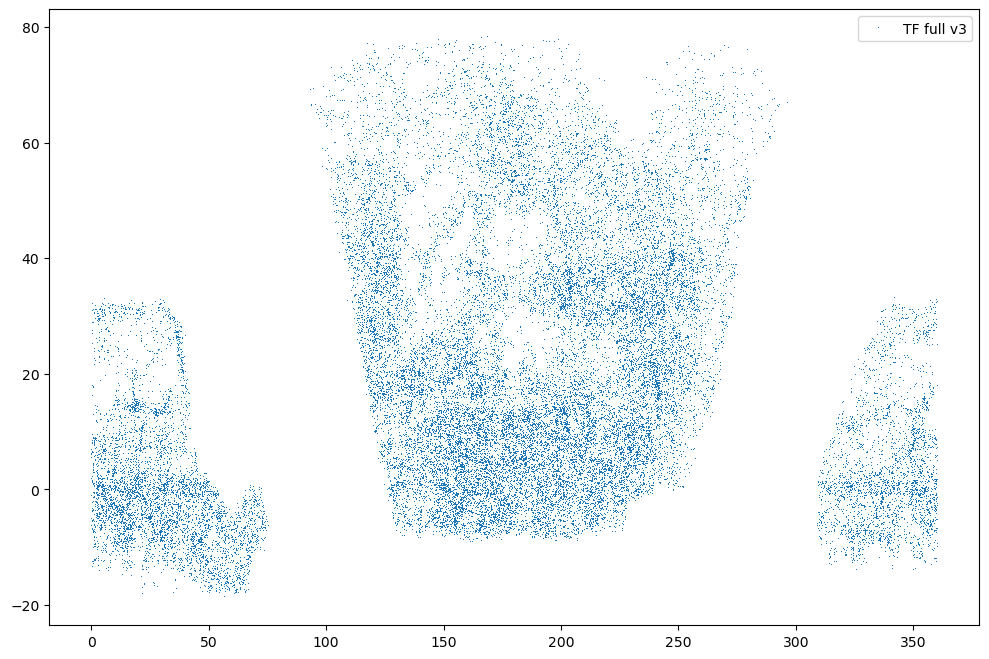

In [10]:
plt.figure(figsize=(12, 8)) 
plt.plot(d_data['RA'], d_data['DEC'], ',', ms=1, alpha=1, label=data_label)
plt.legend()

In [ ]:
m_data = fits.open(CONFIG.mock_tf_full_data.format(phase=0, real=0))[1].data
m_data.names, m_data.size

(['RA',
  'DEC',
  'ZOBS',
  'ZCOS',
  'vx',
  'vy',
  'vz',
  'DWARF',
  'MAIN',
  'LOGVROT',
  'LOGVROT_ERR',
  'R_ABSMAG_SB26',
  'R_ABSMAG_SB26_ERR',
  'R_ABSMAG_SB26_TRUE',
  'LOGDIST_TRUE',
  'LOGDIST',
  'LOGDIST_ERR',
  'Y1_COMP',
  'Y3_COMP'],
 175733)

Text(0.5, 1.0, 'Mock vs data clustering data catalog')

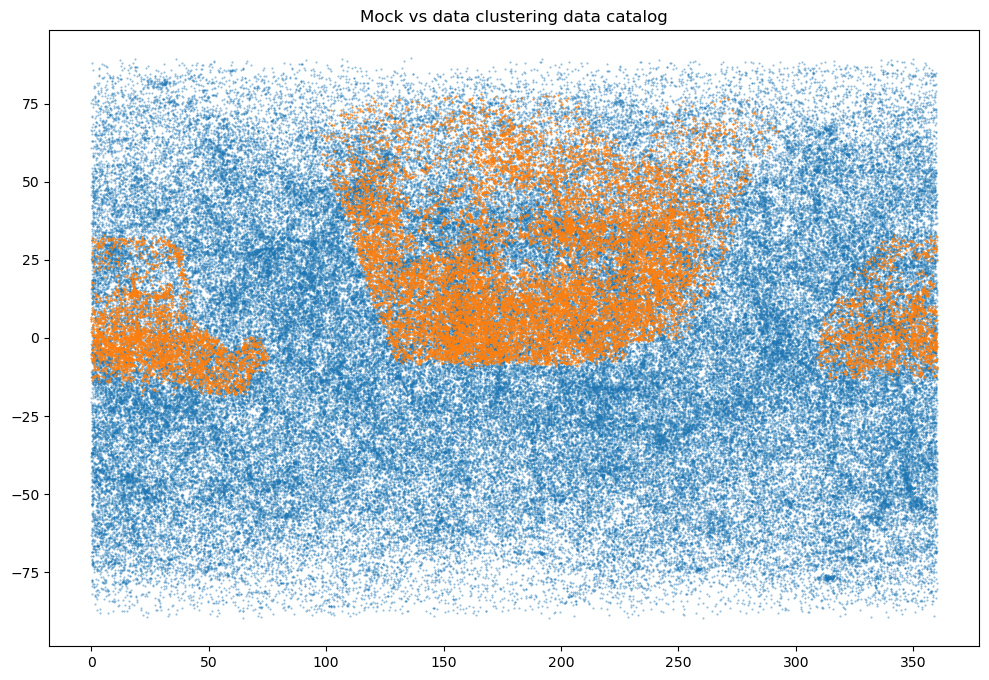

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=0.5)
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=1, alpha=1)

plt.title('Mock vs data clustering data catalog')

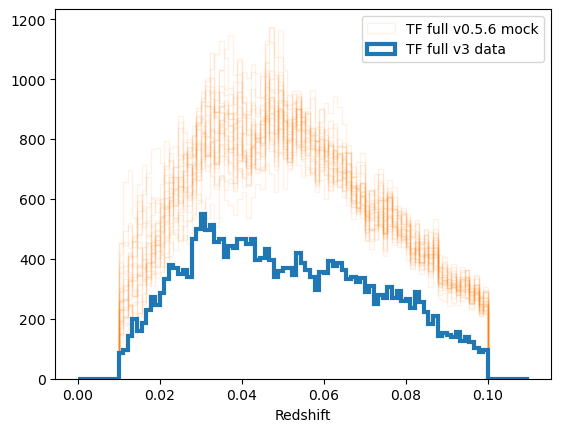

In [22]:
zbins = np.linspace(0, 0.11, 100)

for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(CONFIG.mock_tf_full_data.format(phase=phase, real=real))[1].data
        #m_app_mag = m_data_temp['app_mag']
        m_zobs = m_data_temp['ZOBS']
        #m_abs_mag = m_data_temp['abs_mag']
        m_comp = m_data_temp['Y3_COMP']
        
        
        mask = (
                (m_comp > np.random.rand(m_comp.size)) & 
                (m_zobs > 0.01) & 
                (m_zobs < 0.10)
                )

        label = f'TF full {CONFIG.version_tf_full} mock' if phase == 0 and real ==0 else None 
        _=plt.hist(m_zobs[mask], color='C1', bins=zbins, histtype='step', alpha=0.1, label=label)

        
_=plt.hist(d_data['Z'], bins=zbins, histtype='step', lw=3, 
           label=f'TF full {CONFIG.data_tf_full_version} data')
plt.xlabel('Redshift')
plt.legend()

In [21]:
area = 9146 # sq deg
zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=41253.):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area


In [23]:
m_nzs = []
for phase in range(25):
    for real in range(27):
        m_data_temp = fits.open(cfg.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'])
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(675, 99)


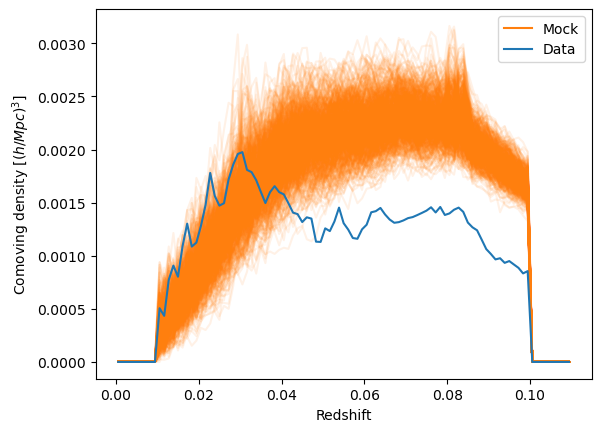

In [24]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.1)
plt.plot([], [], 'C1-', label='Mock')

d_nz = get_nz(d_data['Z'])
plt.plot(zcen, d_nz, 'C0-', label='Data')

plt.ylabel('Comoving density [${(h/Mpc)}^3$]')
plt.xlabel('Redshift')
plt.legend()